In [4]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/train_df.parquet')

In [6]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,source_user_type,destination_user_type,success
duration[μs],str,str,str,str,enum,enum,enum,enum,enum,bool
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C12889""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
12d 8h 33m 10s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1191""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true


In [18]:
user_mixing = df.group_by(['source_computer', 'source_user_type']).len().collect()

In [ ]:
# Prop of mixed machines and dominant type share for mixed machine
user_mixing = df.group_by(['source_computer', 'source_user_type']).len().with_columns(
    pl.col('len').sum().over('source_computer').alias('total_len')).with_columns(
        (pl.col('len') / pl.col('total_len')).alias('type_share'))

user_mixing = user_mixing.group_by('source_computer').agg(
        pl.col('source_user_type').n_unique().alias('n_user_types'),
        pl.col('type_share').max().alias('top_type_share'))

user_mixing = user_mixing.select((pl.col('n_user_types') > 1).mean().alias('share_mixed_machines'),
            pl.col('top_type_share').median().alias('median_top_type_share')).collect()

user_mixing

share_mixed_machines,median_top_type_share
f64,f64
0.898935,0.657599


### Frequency

In [7]:
def counts_to_cdf(counts):
    frequencies = counts['len'].to_list()
    sorted_freqs = np.sort(frequencies)
    cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
    return sorted_freqs, cdf

def plot_counts(column):
    if column in ('source_computer', 'source_user@domain'):
        user_type_col = 'source_user_type'
        plt_title = 'Authentications requests sent'
    else:
        user_type_col = 'destination_user_type'
        plt_title = 'Authentication Requests Recieved'

    human_counts = df.filter(pl.col(user_type_col) == 'human'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    machine_counts = df.filter(pl.col(user_type_col) == 'machine'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    anon_counts = df.filter(pl.col(user_type_col) == 'anon'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    system_counts = df.filter(pl.col(user_type_col) == 'system'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    human_sf, human_cdf = counts_to_cdf(human_counts)
    machine_sf, machine_cdf = counts_to_cdf(machine_counts)
    system_sf, system_cdf = counts_to_cdf(system_counts)
    anon_sf, anon_cdf = counts_to_cdf(anon_counts)


    plt.figure(figsize=(10, 6))
    plt.title(plt_title)
    plt.xscale('log')
    plt.xlabel('frequency')
    plt.ylabel('prop_of_computers_below_that_frequency')
    plt.plot(human_sf, human_cdf, alpha=0.5, label='human')
    plt.plot(machine_sf, machine_cdf, alpha=0.5, label='machine')
    plt.plot(system_sf, system_cdf, alpha=0.5, label='system')
    plt.plot(anon_sf, anon_cdf, alpha=0.5, label='anon')
    plt.legend()
    plt.show()

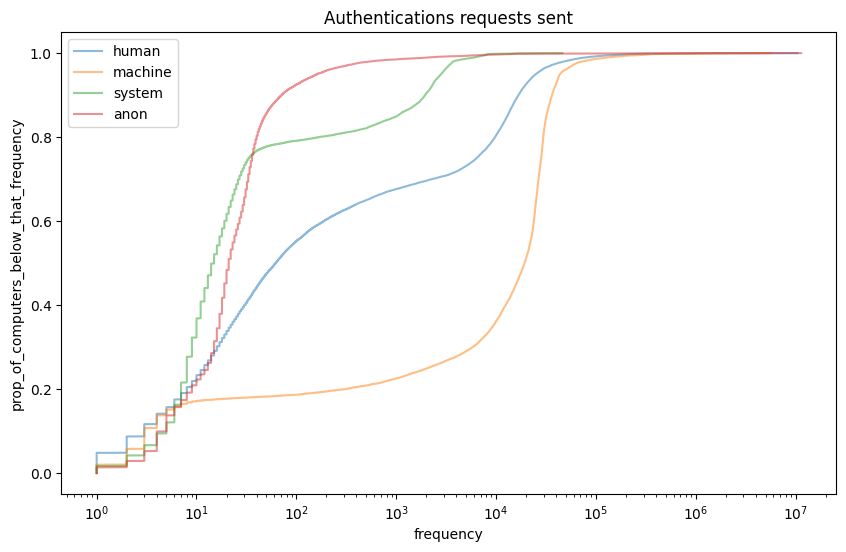

In [9]:
plot_counts(column='source_user@domain')

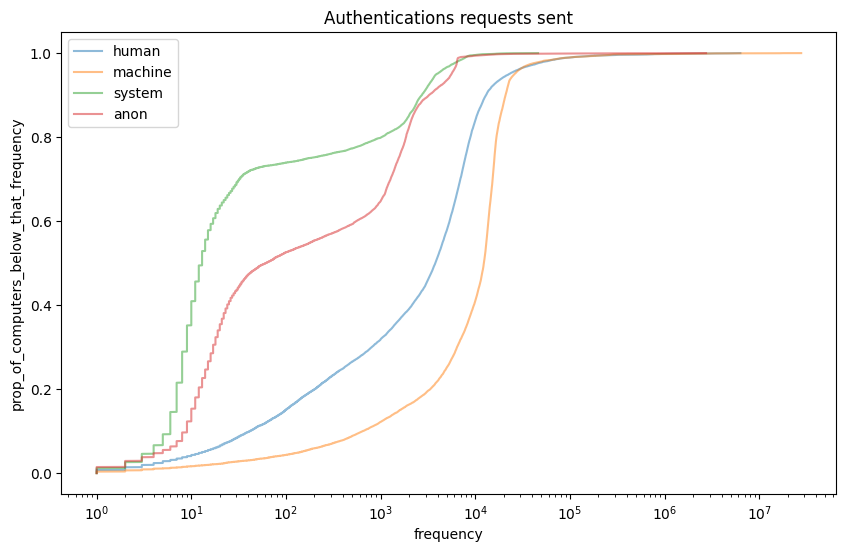

In [21]:
# Human machine activity is more seperable when viewed across multiple machines
plot_counts(column='source_computer')